In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 315kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.69MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.5MB/s]


Epoch 1/5
loss: 0.5993 - accuracy: 0.7761 - val_loss: 0.4410 - val_accuracy: 0.8388
Epoch 2/5
loss: 0.3915 - accuracy: 0.8528 - val_loss: 0.3651 - val_accuracy: 0.8663
Epoch 3/5
loss: 0.3348 - accuracy: 0.8764 - val_loss: 0.3395 - val_accuracy: 0.8723
Epoch 4/5
loss: 0.3003 - accuracy: 0.8885 - val_loss: 0.3278 - val_accuracy: 0.8770
Epoch 5/5
loss: 0.2768 - accuracy: 0.8973 - val_loss: 0.3340 - val_accuracy: 0.8785


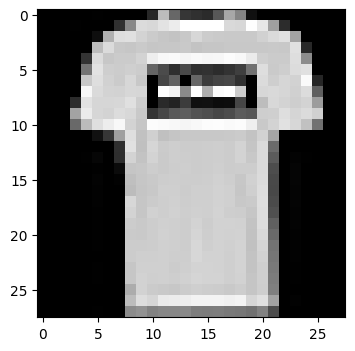

Предсказанный класс: 0, Истинный класс: 0


In [3]:
# Загрузка данных Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),  # сразу приводит к [0,1] и добавляет канал (C, H, W)
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                             download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                            download=True, transform=transform)

# Разделение train на train/val (последние 10% для валидации, как в Keras)
val_size = int(0.1 * len(trainset))
train_size = len(trainset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(
    trainset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)

batch_size = 16
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                           shuffle=False, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

# Определение модели
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32,
                               kernel_size=3, stride=2, padding=1)  # padding='same' при stride=2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)  # padding=0 по умолчанию (valid)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)  # padding='same'
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 2 * 2, 64)  # после вычислений размер карты 2x2
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.relu(self.conv3(x))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)          # без softmax, будет включён в loss
        return x

model = FashionCNN().to(device)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()  # соответствует categorical_crossentropy с softmax
optimizer = optim.Adam(model.parameters())

# Метрика accuracy
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return (preds == labels).float().mean()

epochs = 5
for epoch in range(epochs):
    # тренировочная фаза
    model.train()
    train_loss = 0.0
    train_acc = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_acc += accuracy(outputs, labels).item() * images.size(0)

    train_loss /= len(train_dataset)
    train_acc /= len(train_dataset)

    # валидационная фаза
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_acc += accuracy(outputs, labels).item() * images.size(0)

    val_loss /= len(val_dataset)
    val_acc /= len(val_dataset)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")


img_tensor, true_label = trainset[1]
img_np = img_tensor.numpy().squeeze()

plt.figure(figsize=(4, 4))
plt.imshow(img_np, cmap='gray')
plt.show()

# Добавляем размерность batch
img_batch = img_tensor.unsqueeze(0).to(device)  # (1, 1, 28, 28)

model.eval()
with torch.no_grad():
    logits = model(img_batch)
    probs = torch.softmax(logits, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()

print(f"Предсказанный класс: {pred_class}, Истинный класс: {true_label}")

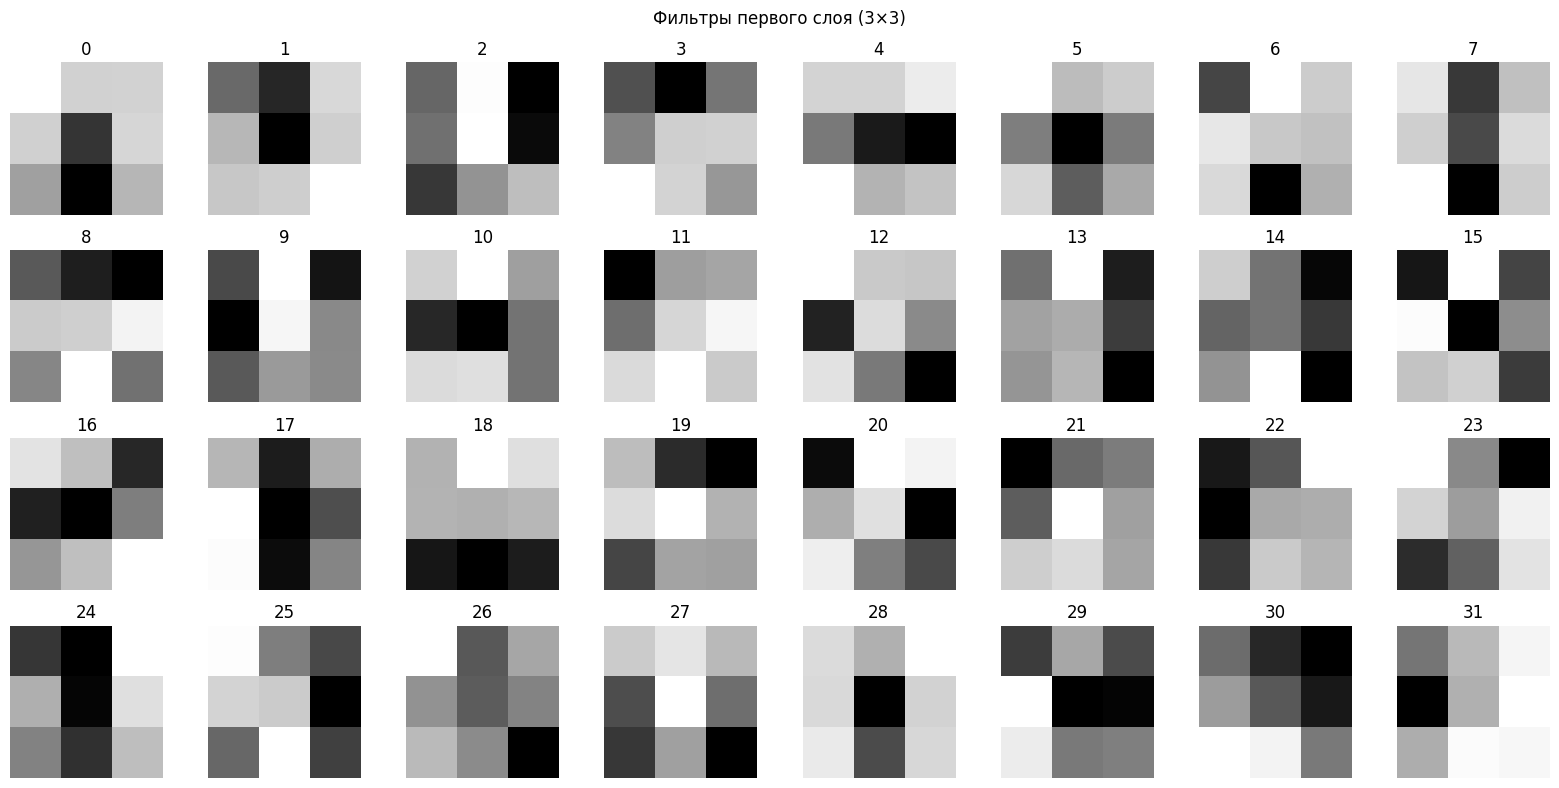

In [4]:
# Веса первого свёрточного слоя
weights = model.conv1.weight.data.cpu()  # форма (32, 1, 3, 3)

# Визуализируем все 32 фильтра
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < len(weights):
        # фильтр имеет один входной канал, берём weights[i, 0]
        ax.imshow(weights[i, 0], cmap='gray')
        ax.axis('off')
        ax.set_title(f'{i}')
plt.suptitle('Фильтры первого слоя (3×3)')
plt.tight_layout()
plt.show()